In [1]:
# Run this ONCE to install all libraries
!pip install pandas matplotlib seaborn scikit-learn

# Then import them at the top of every notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

print('All libraries loaded!')

All libraries loaded!


In [2]:
import pandas as pd

# Load the data (change path if needed)
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# First look at the data
print('Shape:', df.shape)  # rows x columns
print('\nFirst 5 rows:')
df.head()

Shape: (1470, 35)

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print(df.columns.tolist())


['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [4]:
# Check for missing values (null = missing)
print('Missing values in each column:')
print(df.isnull().sum())

# Check attrition split
print('\nHow many left vs stayed?')
print(df['Attrition'].value_counts())
print('\nAs percentages:')
print(df['Attrition'].value_counts(normalize=True).round(2) * 100)

Missing values in each column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

In [8]:
!pip install pandasql

import pandasql as psql

pq = lambda q: psql.sqldf(q, globals())

print('SQL ready!')

SQL ready!


In [9]:
query1 = """
SELECT 
    Department,
    COUNT(*) as TotalEmployees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) as Left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 
        1
    ) as AttritionRate
FROM df
GROUP BY Department
ORDER BY AttritionRate DESC
"""

result1 = pq(query1)
print(result1)


               Department  TotalEmployees  Left  AttritionRate
0                   Sales             446    92           20.6
1         Human Resources              63    12           19.0
2  Research & Development             961   133           13.8


In [10]:
query2 = """
SELECT
    CASE
        WHEN MonthlyIncome < 3000  THEN '1. Low (<3k)'
        WHEN MonthlyIncome < 6000  THEN '2. Mid (3k-6k)'
        WHEN MonthlyIncome < 10000 THEN '3. High (6k-10k)'
        ELSE '4. Very High (10k+)'
    END as SalaryBand,
    COUNT(*) as Employees,
    SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) as Left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) / COUNT(*),
        1
    ) as AttritionRate
FROM df
GROUP BY SalaryBand
ORDER BY SalaryBand
"""
print(pq(query2))

            SalaryBand  Employees  Left  AttritionRate
0         1. Low (<3k)        395   113           28.6
1       2. Mid (3k-6k)        519    66           12.7
2     3. High (6k-10k)        275    33           12.0
3  4. Very High (10k+)        281    25            8.9


In [11]:
query3 = """
SELECT
    CASE
        WHEN Age < 25 THEN '18-24'
        WHEN Age < 35 THEN '25-34'
        WHEN Age < 45 THEN '35-44'
        WHEN Age < 55 THEN '45-54'
        ELSE '55+'
    END as AgeGroup,
    COUNT(*) as Employees,
    SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) as Left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*),
        1
    ) as AttritionRate
FROM df
GROUP BY AgeGroup
ORDER BY AgeGroup
"""
print(pq(query3))

  AgeGroup  Employees  Left  AttritionRate
0    18-24         97    38           39.2
1    25-34        554   112           20.2
2    35-44        505    51           10.1
3    45-54        245    25           10.2
4      55+         69    11           15.9


In [12]:
query4 = """
SELECT
    JobSatisfaction,
    CASE JobSatisfaction
        WHEN 1 THEN 'Very Low'
        WHEN 2 THEN 'Low'
        WHEN 3 THEN 'Medium'
        WHEN 4 THEN 'High'
    END as SatisfactionLabel,
    COUNT(*) as Employees,
    SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) as Left,
    ROUND(
        100.0 * SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)/COUNT(*),
        1
    ) as AttritionRate
FROM df
GROUP BY JobSatisfaction
ORDER BY JobSatisfaction
"""
print(pq(query4))

# Save all results to CSV for Power BI
pq(query1).to_csv('../data/sql_dept.csv', index=False)
pq(query2).to_csv('../data/sql_salary.csv', index=False)
pq(query3).to_csv('../data/sql_age.csv', index=False)
pq(query4).to_csv('../data/sql_satisfaction.csv', index=False)
print('Saved all SQL results!')

   JobSatisfaction SatisfactionLabel  Employees  Left  AttritionRate
0                1          Very Low        289    66           22.8
1                2               Low        280    46           16.4
2                3            Medium        442    73           16.5
3                4              High        459    52           11.3
Saved all SQL results!


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Chart settings ready!')

Chart settings ready!


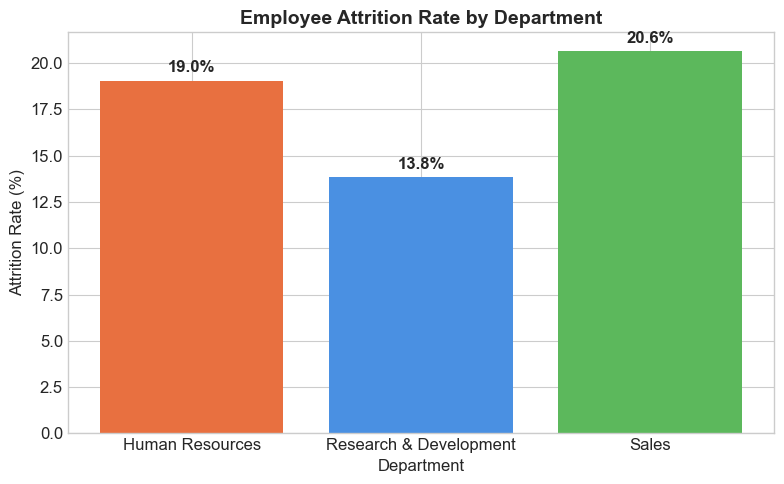

In [14]:
# Calculate attrition rate by department
dept = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').mean() * 100
).reset_index()
dept.columns = ['Department', 'AttritionRate']

# Create bar chart
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(dept['Department'], dept['AttritionRate'], color=['#E87040','#4A90E2','#5CB85C'])
ax.set_title('Employee Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Department')
# Add value labels on bars
for bar, val in zip(bars, dept['AttritionRate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/chart_dept.png', dpi=150, bbox_inches='tight')
plt.show()

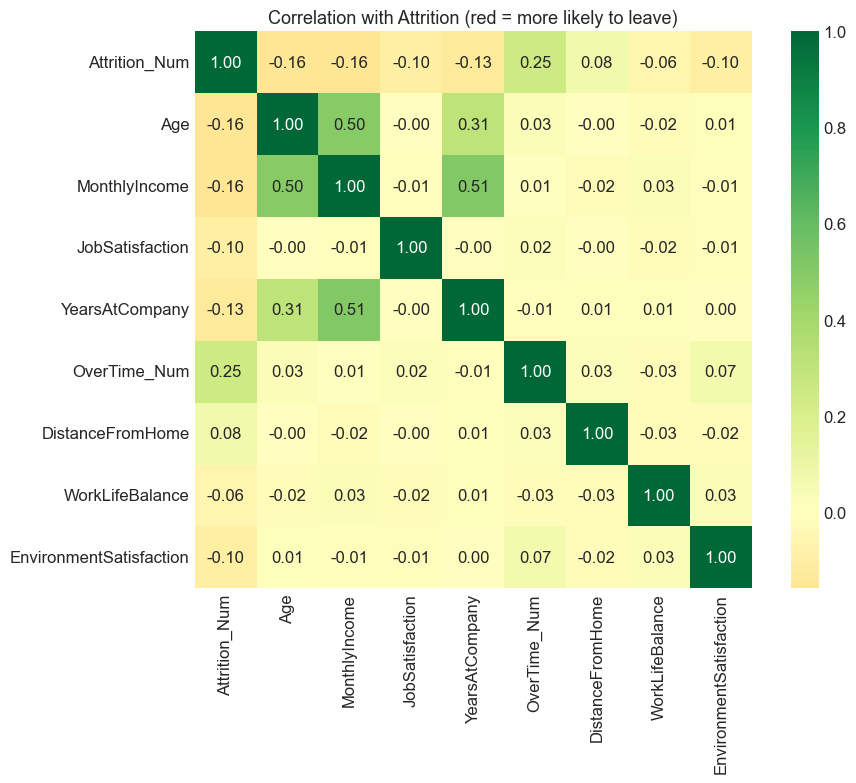

In [15]:
# Convert Attrition to 0/1 for correlation
df['Attrition_Num'] = (df['Attrition'] == 'Yes').astype(int)

# Select numeric columns only
numeric_cols = ['Attrition_Num','Age','MonthlyIncome','JobSatisfaction',
                'YearsAtCompany','OverTime','DistanceFromHome',
                'WorkLifeBalance','EnvironmentSatisfaction']

# Convert OverTime to numeric
df['OverTime_Num'] = (df['OverTime'] == 'Yes').astype(int)
numeric_cols = [c.replace('OverTime','OverTime_Num') for c in numeric_cols]

corr_df = df[['Attrition_Num','Age','MonthlyIncome','JobSatisfaction',
              'YearsAtCompany','OverTime_Num','DistanceFromHome',
              'WorkLifeBalance','EnvironmentSatisfaction']]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax)
ax.set_title('Correlation with Attrition (red = more likely to leave)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/chart_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

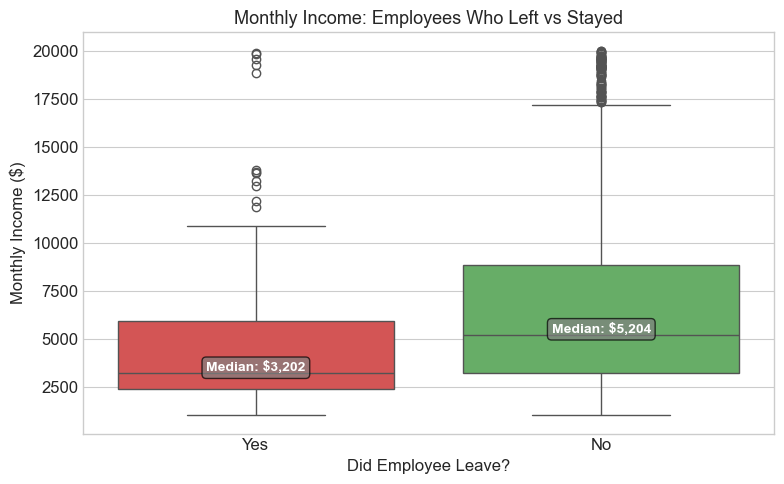

In [18]:
fig, ax = plt.subplots(figsize=(8,5))

# FIXED: added hue='Attrition' and legend=False
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            hue='Attrition', legend=False,
            palette={'No':'#5CB85C','Yes':'#E84040'}, ax=ax)

ax.set_title('Monthly Income: Employees Who Left vs Stayed', fontsize=13)
ax.set_xlabel('Did Employee Leave?')
ax.set_ylabel('Monthly Income ($)')

# Add median labels
for i, grp in enumerate(['Yes', 'No']):
    med = df[df['Attrition']==grp]['MonthlyIncome'].median()
    ax.text(i, med+100, f'Median: ${med:,.0f}',
            ha='center', fontsize=10, fontweight='bold', color='white',
            bbox=dict(boxstyle='round', fc='gray', alpha=0.7))

plt.tight_layout()
plt.savefig('../data/chart_salary.png', dpi=150, bbox_inches='tight')
plt.show()

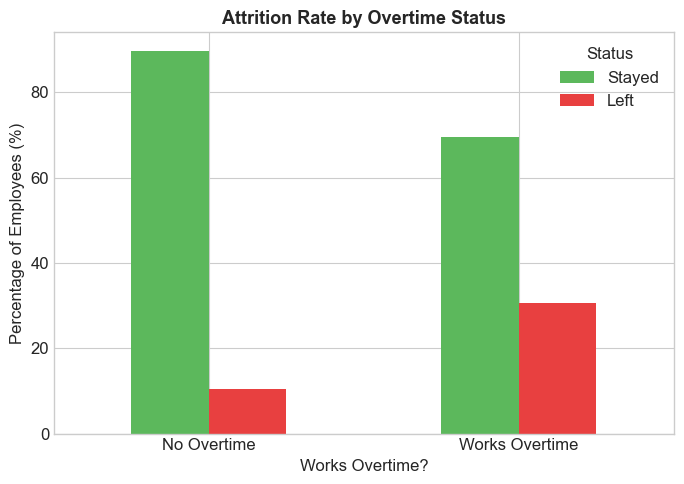

Attrition rate WITHOUT overtime: 10.4 %
Attrition rate WITH overtime: 30.5 %


In [19]:
overtime_attr = df.groupby(['OverTime','Attrition']).size().unstack()
overtme_pct = overtime_attr.div(overtime_attr.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7,5))
overtme_pct.plot(kind='bar', color=['#5CB85C','#E84040'], ax=ax, width=0.5)
ax.set_title('Attrition Rate by Overtime Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Works Overtime?')
ax.set_ylabel('Percentage of Employees (%)')
ax.legend(['Stayed','Left'], title='Status')
ax.set_xticklabels(['No Overtime','Works Overtime'], rotation=0)
plt.tight_layout()
plt.savefig('../data/chart_overtime.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the numbers
print('Attrition rate WITHOUT overtime:', 
      round(df[df['OverTime']=='No']['Attrition'].eq('Yes').mean()*100,1),'%')
print('Attrition rate WITH overtime:',
      round(df[df['OverTime']=='Yes']['Attrition'].eq('Yes').mean()*100,1),'%')

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Make a copy so we don't mess up original data
df_ml = df.copy()


df_ml = df_ml.drop(columns=['Over18', 'EmployeeCount', 'StandardHours', 'EmployeeNumber'])

# Convert Yes/No and Male/Female columns to 0 and 1
df_ml['Attrition'] = (df_ml['Attrition'] == 'Yes').astype(int)
df_ml['OverTime']  = (df_ml['OverTime']  == 'Yes').astype(int)
df_ml['Gender']    = (df_ml['Gender']    == 'Male').astype(int)

# Convert ALL remaining text columns to numbers using get_dummies
# This handles BusinessTravel, Department, JobRole, MaritalStatus, EducationField
df_ml = pd.get_dummies(df_ml, columns=[
    'BusinessTravel',    # ← this was the missing one causing your error
    'Department',
    'JobRole',
    'MaritalStatus',
    'EducationField'
], drop_first=False)

# Quick check — no text columns should remain
text_cols = df_ml.select_dtypes(include='object').columns.tolist()
if text_cols:
    print('⚠️ Still has text columns:', text_cols)
else:
    print('✅ All columns are now numeric! Shape:', df_ml.shape)

✅ All columns are now numeric! Shape: (1470, 52)


In [29]:
# Drop columns that shouldn't influence the model
cols_to_drop = [
    'Attrition',        # the target variable
    'Attrition_Num',    # ← THIS was the leak! Created in Phase 4 heatmap cell
    'OverTime_Num',     # also created in Phase 4
]

X = df_ml.drop(columns=cols_to_drop, errors='ignore')  # errors='ignore' skips if not found
y = df_ml['Attrition']

# Quick sanity check
print('Attrition in X columns?', 'Attrition' in X.columns)      # must say False
print('Attrition_Num in X columns?', 'Attrition_Num' in X.columns)  # must say False
print(f'Training rows: {len(X_train)}')
print(f'Testing rows:  {len(X_test)}')
print(f'Features used: {X.shape[1]}')

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Attrition in X columns? False
Attrition_Num in X columns? False
Training rows: 1176
Testing rows:  294
Features used: 49


In [30]:
# Train the model (this takes a few seconds)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Test it on unseen data
y_pred = model.predict(X_test)

# How well did it do?
print('Model Accuracy:', round(accuracy_score(y_test, y_pred)*100, 1), '%')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred, target_names=['Stayed','Left']))

Model Accuracy: 84.7 %

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.99      0.92       247
        Left       0.67      0.09      0.15        47

    accuracy                           0.85       294
   macro avg       0.76      0.54      0.53       294
weighted avg       0.82      0.85      0.79       294



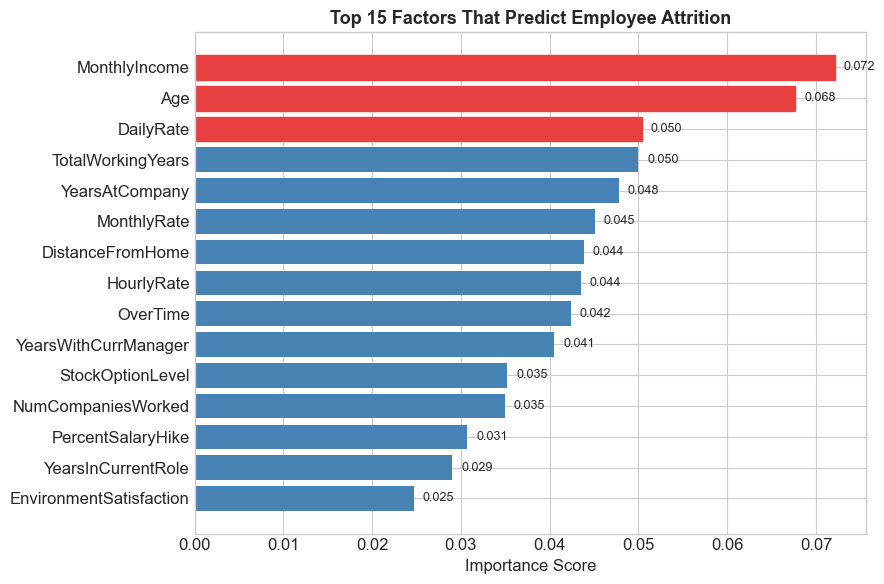

Top 3 attrition drivers:
  MonthlyIncome: 0.072
  Age: 0.068
  DailyRate: 0.050


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importance scores
importances = pd.Series(model.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

# Plot it
fig, ax = plt.subplots(figsize=(9,6))
bars = ax.barh(top15.index, top15.values, color='steelblue')
ax.set_title('Top 15 Factors That Predict Employee Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')

# Highlight top 3
for i, (bar, val) in enumerate(zip(bars, top15.values)):
    if i >= 12:  # top 3
        bar.set_color('#E84040')
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/chart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 3 attrition drivers:')
for feat, imp in importances.nlargest(3).items():
    print(f'  {feat}: {imp:.3f}')